# Import Libraries and Load dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data=pd.read_csv("netflix_titles.csv")
display(data)
data.info() #information

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020.0,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021.0,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021.0,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021.0,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021.0,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
5393,s5394,TV Show,Breakout,NaN,"Jeanette Aw, Elvin Ng, Zhou Ying, Christopher ...",NaN,"July 1, 2017",2010.0,TV-14,1 Season,"International TV Shows, TV Dramas",After losing her family in a suspicious car cr...
5394,s5395,Movie,Hans Teeuwen: Real Rancour,Doesjka van Hoogdalem,Hans Teeuwen,Netherlands,"July 1, 2017",2018.0,TV-MA,86 min,Stand-Up Comedy,Comedian Hans Teeuwen rebels against political...
5395,s5396,TV Show,Intersection,NaN,"İbrahim Çelikkol, Belçim Bilgin, Alican Yüceso...",Turkey,"July 1, 2017",2016.0,TV-MA,3 Seasons,"International TV Shows, Romantic TV Shows, TV ...",Two wealthy businessmen with car obsessions cr...
5396,s5397,Movie,Lal Patthar,Sushil Majumdar,"Raaj Kumar, Hema Malini, Rakhee Gulzar, Vinod ...",India,"July 1, 2017",1971.0,TV-14,153 min,"Classic Movies, Dramas, International Movies","A vain, self-righteous nobleman falls in love ..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5398 entries, 0 to 5397
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       5398 non-null   object 
 1   type          5398 non-null   object 
 2   title         5397 non-null   object 
 3   director      3515 non-null   object 
 4   cast          4903 non-null   object 
 5   country       4735 non-null   object 
 6   date_added    5397 non-null   object 
 7   release_year  5397 non-null   float64
 8   rating        5397 non-null   object 
 9   duration      5397 non-null   object 
 10  listed_in     5397 non-null   object 
 11  description   5397 non-null   object 
dtypes: float64(1), object(11)
memory usage: 506.2+ KB


# Feature description

In [2]:
for col in data.columns:
    
    if data[col].dtype in ["float64", "int64"]:
        print(f"Feature: {col}")
        print("Min:", data[col].min())
        print("Max:", data[col].max())
        print()
        
    else:
        print(f"Feature: {col}")
        print("Unique Values:", data[col].unique())
        print("No. of Unique Values:", data[col].nunique())
        print()

Feature: show_id
Unique Values: ['s1' 's2' 's3' ... 's5396' 's5397' 's5398']
No. of Unique Values: 5398

Feature: type
Unique Values: ['Movie' 'TV Show' 'TV Sh']
No. of Unique Values: 3

Feature: title
Unique Values: ['Dick Johnson Is Dead' 'Blood & Water' 'Ganglands' ... 'Intersection'
 'Lal Patthar' nan]
No. of Unique Values: 5397

Feature: director
Unique Values: ['Kirsten Johnson' nan 'Julien Leclercq' ... 'Lekh Tandon'
 'Doesjka van Hoogdalem' 'Sushil Majumdar']
No. of Unique Values: 2721

Feature: cast
Unique Values: [nan
 'Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Maake Ka-Ncube, Odwa Gwanya, Mekaila Mathys, Sandi Schultz, Duane Williams, Shamilla Miller, Patrick Mofokeng'
 'Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera'
 ... 'Ha

# Statistical Summary

In [3]:
data.describe(include="object")

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,5398,5398,5397,3515,4903,4735,5397,5397,5397,5397,5397
unique,5398,3,5397,2721,4749,475,1177,11,208,430,5381
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",United States,"July 1, 2021",TV-MA,1 Season,Stand-Up Comedy,"Paranormal activity at a lush, abandoned prope..."
freq,1,3464,1,17,14,1545,60,2246,1258,239,4


# Data Cleaning
# Changing Data Type

In [4]:
#change datatype
data["date_added"] = pd.to_datetime(data["date_added"], errors='coerce')

In [5]:
#checking how many null vale
data.isnull().sum()

show_id            0
type               0
title              1
director        1883
cast             495
country          663
date_added         1
release_year       1
rating             1
duration           1
listed_in          1
description        1
dtype: int64

In [6]:
# checking percentage of null value
np.round(data.isnull().sum()/5398*100,2)

show_id          0.00
type             0.00
title            0.02
director        34.88
cast             9.17
country         12.28
date_added       0.02
release_year     0.02
rating           0.02
duration         0.02
listed_in        0.02
description      0.02
dtype: float64

In [7]:
data["director"]=data["director"].fillna("N/A")

In [8]:
data["rating"].mode()

0    TV-MA
Name: rating, dtype: object

In [9]:
data["rating"]=data["rating"].fillna(data["rating"].mode()[0])

In [10]:
data=data.dropna(subset="title")

In [11]:
data.isnull().sum()

show_id           0
type              0
title             0
director          0
cast            494
country         662
date_added        0
release_year      0
rating            0
duration          0
listed_in         0
description       0
dtype: int64

# working with duplicates

In [12]:
data.duplicated().sum()

np.int64(0)

# Finding outliers

In [13]:
data.describe()

,date_added,release_year
count,5397,5397.000000
mean,2020-02-02 21:51:39.722067712,2016.083936
min,2017-07-01 00:00:00,1925.000000
25%,2019-03-04 00:00:00,2016.000000
50%,2020-04-09 00:00:00,2018.000000
75%,2021-02-03 00:00:00,2020.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,7.121457


'Number of Outliers:'

568

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993.0,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
22,s23,Movie,Avvai Shanmughi,K.S. Ravikumar,"Kamal Hassan, Meena, Gemini Ganesan, Heera Raj...",NaN,2021-09-21,1996.0,TV-PG,161 min,"Comedies, International Movies",Newly divorced and denied visitation rights wi...
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,2021-09-21,1998.0,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...
26,s27,Movie,Minsara Kanavu,Rajiv Menon,"Arvind Swamy, Kajol, Prabhu Deva, Nassar, S.P....",NaN,2021-09-21,1997.0,TV-PG,147 min,"Comedies, International Movies, Music & Musicals",A tangled love triangle ensues when a man fall...
41,s42,Movie,Jaws,Steven Spielberg,"Roy Scheider, Robert Shaw, Richard Dreyfuss, L...",United States,2021-09-16,1975.0,PG,124 min,"Action & Adventure, Classic Movies, Dramas",When an insatiable great white shark terrorize...


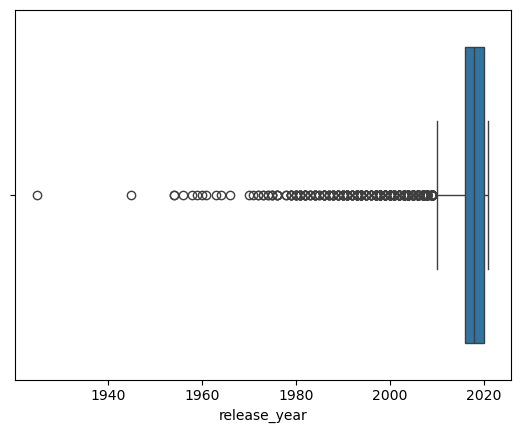

In [14]:
sns.boxplot(data=data,x="release_year")
Q1 = data["release_year"].quantile(0.25)
Q3 = data["release_year"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Identify outliers
outliers = data[(data["release_year"] < lower_bound) | (data["release_year"] > upper_bound)]
display("Number of Outliers:", len(outliers))
display(outliers.head())

Observation:
* Outliers in the release_year feature may affect trend analysis and data distribution.
* However, some extreme years may represent genuine classic or archival content and should be validated before treatment.

In [15]:
# Segment wise Data Analysis

type
Movie      3464
TV Show    1933
Name: count, dtype: int64

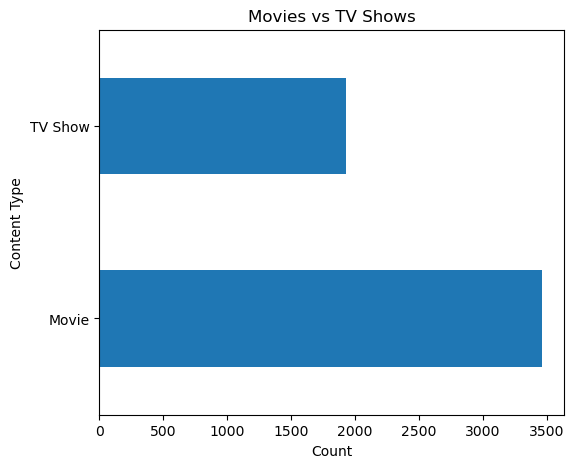

In [16]:
# Content Distribution Analysis
#1. How many total titles are in the dataset?
content_count = data["type"].value_counts()
display(content_count)
plt.figure(figsize=(6,5))
content_count.plot(kind='barh')
plt.title("Movies vs TV Shows")
plt.xlabel("Count")
plt.ylabel("Content Type")
plt.show()

Observation:
  Movies dominate the Netflix platform compared to TV shows, indicating that Netflix focuses more heavily on movie-based content distribution.

country
United States     1999
India              638
United Kingdom     383
Japan              244
Canada             230
France             225
Spain              166
South Korea        158
Germany            124
Mexico             111
Name: count, dtype: int64

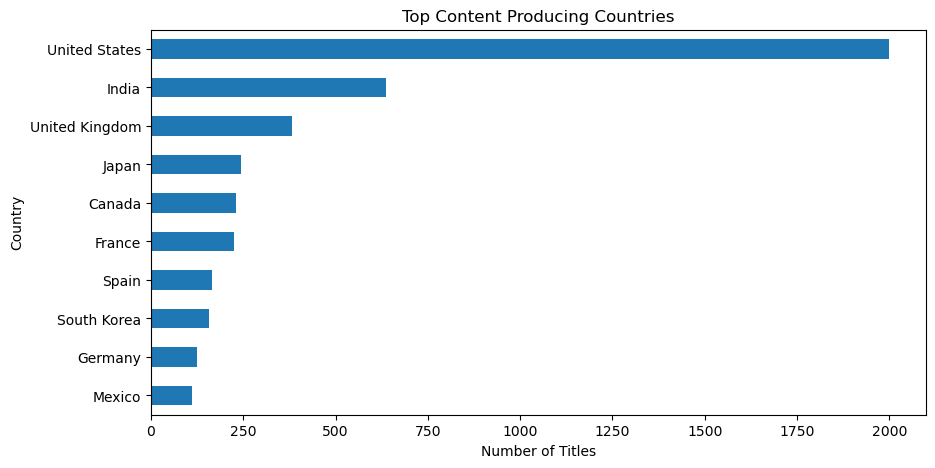

In [17]:
#2. Which countries produce the most Netflix content?
top_countries = (data["country"].str.split(", ").explode().value_counts().head(10))
display(top_countries)
plt.figure(figsize=(10,5))
top_countries.sort_values().plot(kind='barh')
plt.title("Top Content Producing Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

Observation:
  The United States contributes the highest amount of Netflix content, followed by other major entertainment-producing countries.

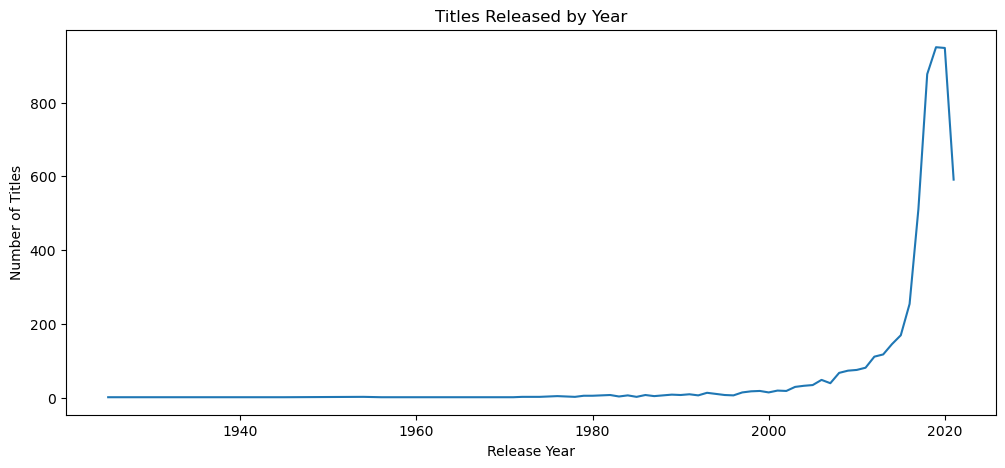

In [18]:
#3. Which release years have the highest number of titles?
release_year = data["release_year"].value_counts().sort_index()
plt.figure(figsize=(12,5))
plt.plot(release_year.index,release_year.values)
plt.title("Titles Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

Observation:
  Netflix content production increased significantly in recent years, indicating rapid platform expansion and growing content acquisition.

rating
TV-MA    2246
TV-14    1373
TV-PG     465
R         367
TV-Y      230
PG-13     226
TV-Y7     209
TV-G      144
PG        123
G          13
NC-17       1
Name: count, dtype: int64

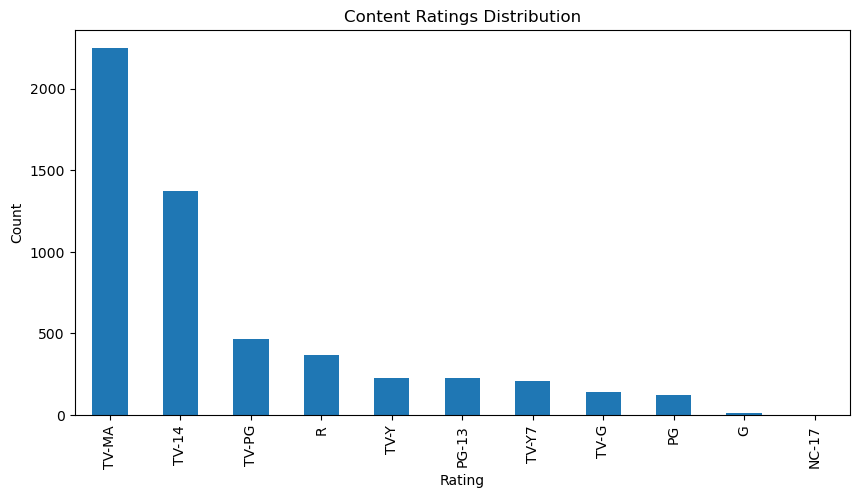

In [19]:
#4. Which ratings are most common on Netflix?
rating_count = data["rating"].value_counts()
display(rating_count)
plt.figure(figsize=(10,5))
rating_count.plot(kind='bar')
plt.title("Content Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

Observation:
 TV-MA and TV-14 ratings dominate Netflix content, suggesting a strong focus on mature and teenage audiences.

listed_in
International Movies        1755
Dramas                      1426
Comedies                    1025
International TV Shows      1000
TV Dramas                    576
Action & Adventure           464
TV Comedies                  436
Romantic Movies              398
Documentaries                389
Children & Family Movies     377
Name: count, dtype: int64

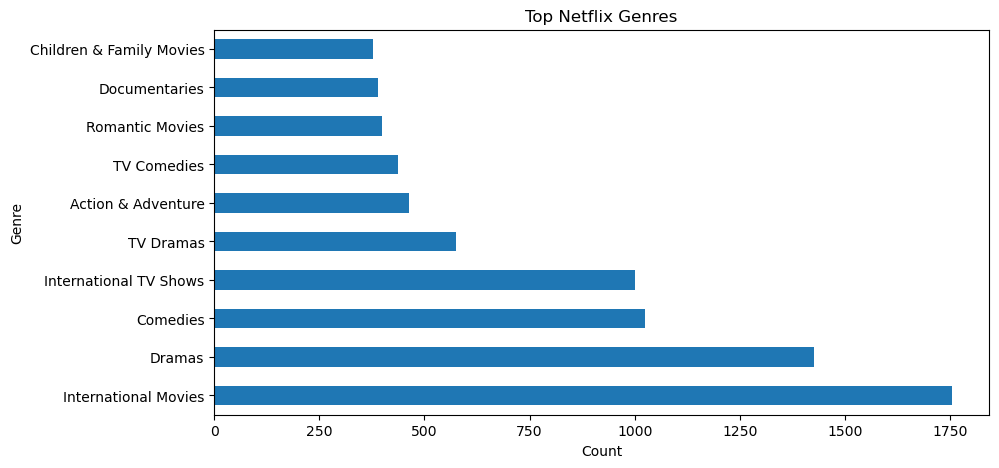

In [20]:
#5. Which genres are most common on Netflix?
genres = (data["listed_in"].str.split(", ").explode().value_counts().head(10))
display(genres)
plt.figure(figsize=(10,5))
genres.plot(kind='barh')
plt.title("Top Netflix Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.xticks(rotation=0)
plt.show()

Observation:
 International Movies, Drama and Comedy are among the most dominant genres on Netflix.

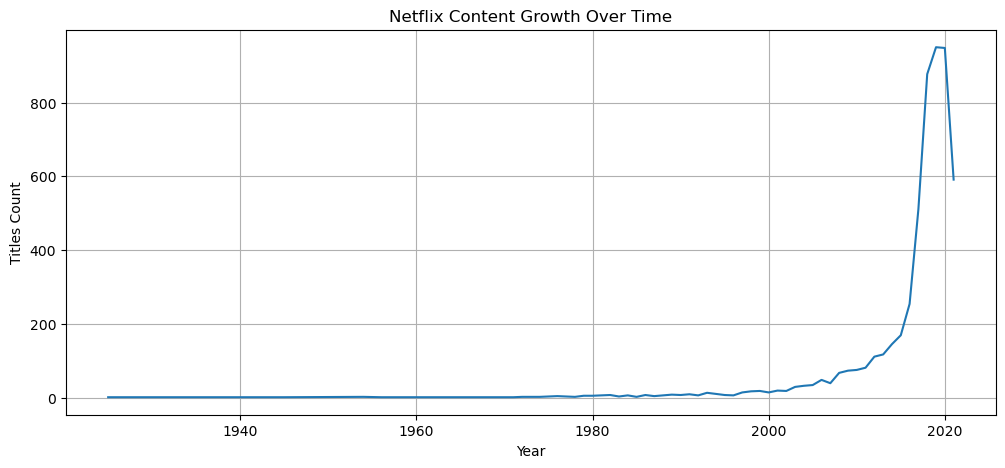

In [21]:
#Time-Based Trend Analysis
#1. How has Netflix content grown over time?
yearly_titles = data["release_year"].value_counts().sort_index()
plt.figure(figsize=(12,5))
plt.plot(yearly_titles.index,yearly_titles.values)
plt.title("Netflix Content Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Titles Count")
plt.grid(True)
plt.show()

Observation:
   Netflix experienced rapid growth in content additions after 2015, showing strong platform expansion.

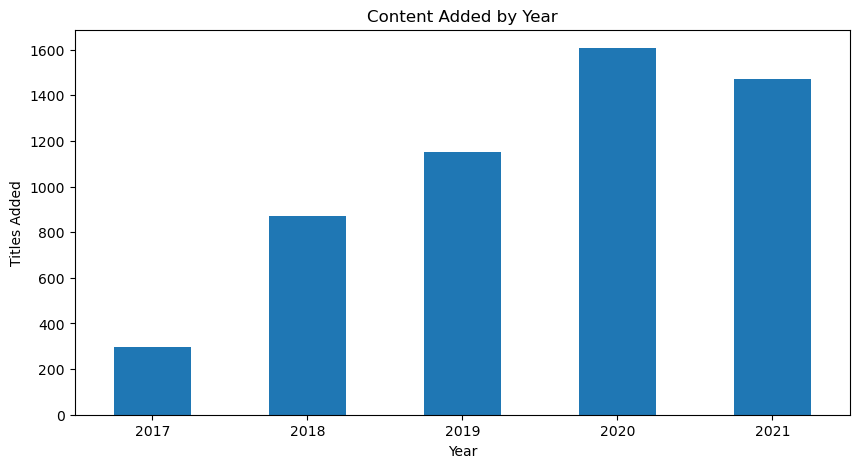

In [22]:
#2. Which years had the highest content additions?
data["added_year"] = data["date_added"].dt.year
added_year = data["added_year"].value_counts().sort_index()
plt.figure(figsize=(10,5))
added_year.plot(kind='bar')
plt.title("Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Titles Added")
plt.xticks(rotation=0)
plt.show()

Observation:
  Certain years show major increases in content additions, reflecting Netflix’s aggressive acquisition strategy.

type,Movie,TV Show
release_year,,
1925.0,0,1
1945.0,0,1
1954.0,2,0
1956.0,1,0
1958.0,1,0
...,...,...
2017.0,352,159
2018.0,558,319
2019.0,562,388


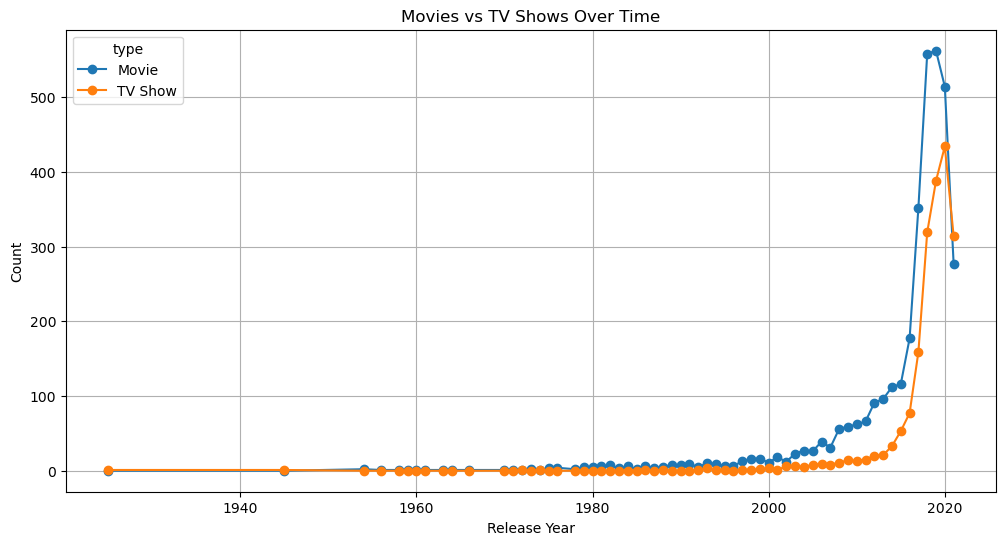

In [23]:
#3. Are Movies or TV Shows increasing faster over time?
content_trend = data.groupby(["release_year", "type"]).size().unstack(fill_value=0)
display(content_trend)
content_trend.plot(figsize=(12,6), marker='o')
plt.title("Movies vs TV Shows Over Time")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.grid(True)
plt.show()

Observation:
  Movies consistently dominate Netflix content growth, although TV show additions have increased steadily in recent years.

month_added
January      338
February     325
March        402
April        479
May          420
June         473
July         548
August       490
September    528
October      482
November     455
December     457
Name: count, dtype: int64

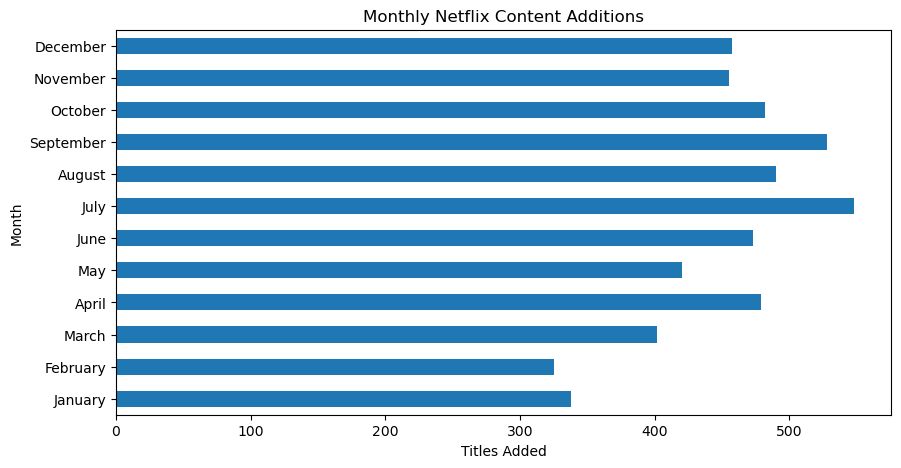

In [24]:
#4. Which months see the highest content additions?
data["month_added"] = data["date_added"].dt.month_name()
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
monthly = data["month_added"].value_counts().reindex(month_order)
display(monthly)
plt.figure(figsize=(10,5))
monthly.plot(kind='barh')
plt.title("Monthly Netflix Content Additions")
plt.xlabel("Titles Added")
plt.ylabel("Month")
plt.show()

Observation:
 Netflix tends to release more content during specific months, indicating seasonal release strategies.

Older Content (<2000)      195
Modern Content (2000+)    5202
dtype: int64

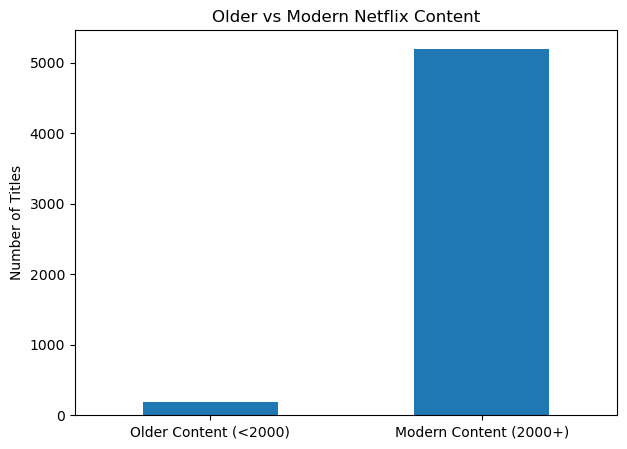

In [25]:
#5. Is older content still common on Netflix?
old_content = data[data["release_year"] < 2000] # Define older content (before 2000)
# Count old vs modern content
content_counts = pd.Series({"Older Content (<2000)": len(old_content),"Modern Content (2000+)": len(data[data["release_year"] >= 2000])})
display(content_counts)
plt.figure(figsize=(7,5))
content_counts.plot(kind='bar')
plt.title("Older vs Modern Netflix Content")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)
plt.show()

Observation:
* The analysis shows that Netflix still contains a noticeable amount of older content, including classic movies and earlier television productions. However, modern content released after 2000 dominates the platform.
* This indicates that Netflix balances audience demand for newly released entertainment with the availability of nostalgic and classic titles.

country
United States     697
Japan             158
United Kingdom    149
South Korea       119
Canada             81
France             62
Spain              50
India              49
Australia          46
Mexico             43
Name: count, dtype: int64

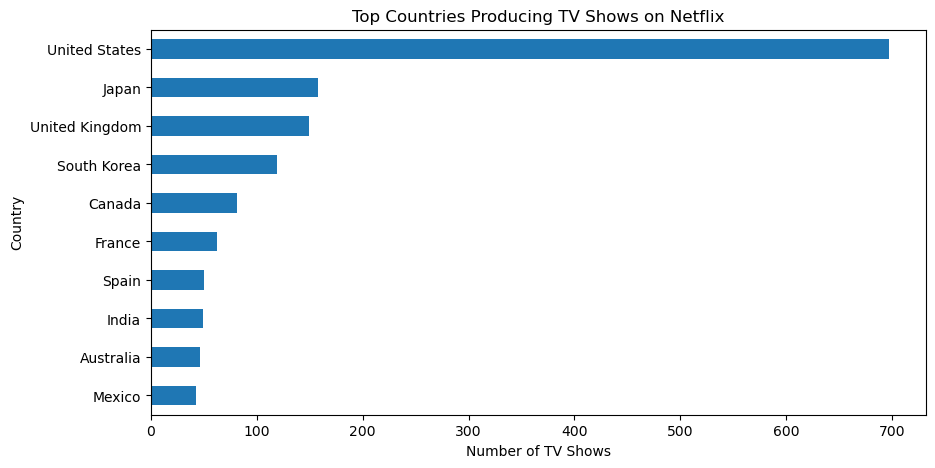

In [26]:
#Country & Genre Analysis
#1. Which country produces the most TV Shows?
tv_shows = data[data["type"] == "TV Show"]
# Split multiple countries and count
country_tv = (tv_shows["country"].str.split(", ").explode().value_counts().head(10))
display(country_tv)
plt.figure(figsize=(10,5))
country_tv.sort_values().plot(kind='barh')
plt.title("Top Countries Producing TV Shows on Netflix")
plt.xlabel("Number of TV Shows")
plt.ylabel("Country")
plt.xticks(rotation=0)
plt.show()

Observation:
* The analysis shows that the United States produces the highest number of TV shows available on Netflix, followed by several other major entertainment-producing countries.
* This reflects the strong influence of established television industries and large-scale content production markets.
* The results also indicate Netflix’s increasing investment in international TV content to support global audience demand.

listed_in
International Movies        1755
Dramas                      1426
Comedies                    1025
Action & Adventure           464
Romantic Movies              398
Documentaries                389
Children & Family Movies     377
Independent Movies           376
Thrillers                    328
Stand-Up Comedy              244
Name: count, dtype: int64

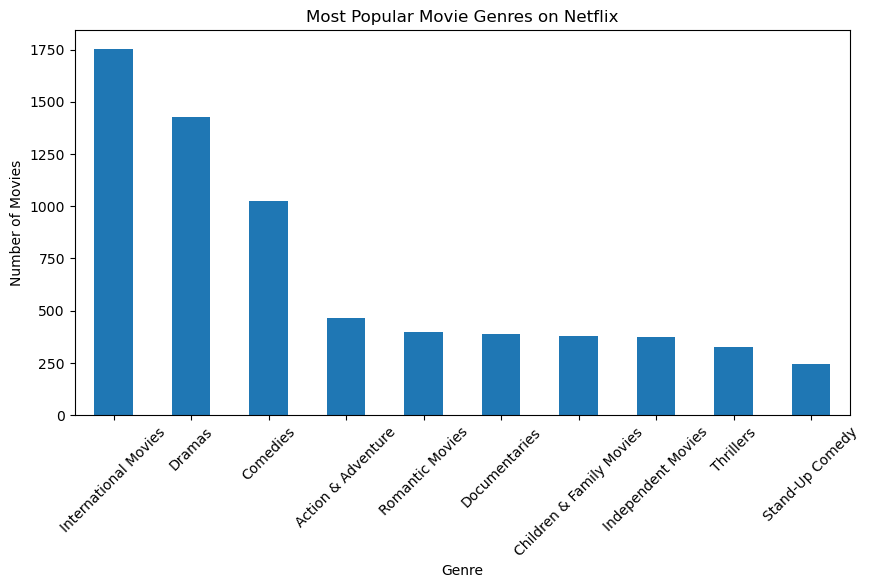

In [27]:
#2. Which genres are most popular in Movies?
movies = data[data["type"] == "Movie"]
# Split genres and count frequency
movie_genres = (movies["listed_in"].str.split(", ").explode().value_counts().head(10))
display(movie_genres)
# Plot
plt.figure(figsize=(10,5))
movie_genres.plot(kind='bar')
plt.title("Most Popular Movie Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.show()

Observation:
* The analysis shows that International Movies, Dramas and Comedy are among the most popular movie genres on Netflix.
* These genres dominate the platform because they appeal to broad audience groups across different regions and age categories.
* The results indicate Netflix’s strong focus on diversified entertainment content to maximize global audience engagement.

country
India             528
France            109
Spain              99
United States      89
Nigeria            75
Philippines        71
United Kingdom     62
Turkey             58
Japan              55
Indonesia          55
Name: count, dtype: int64

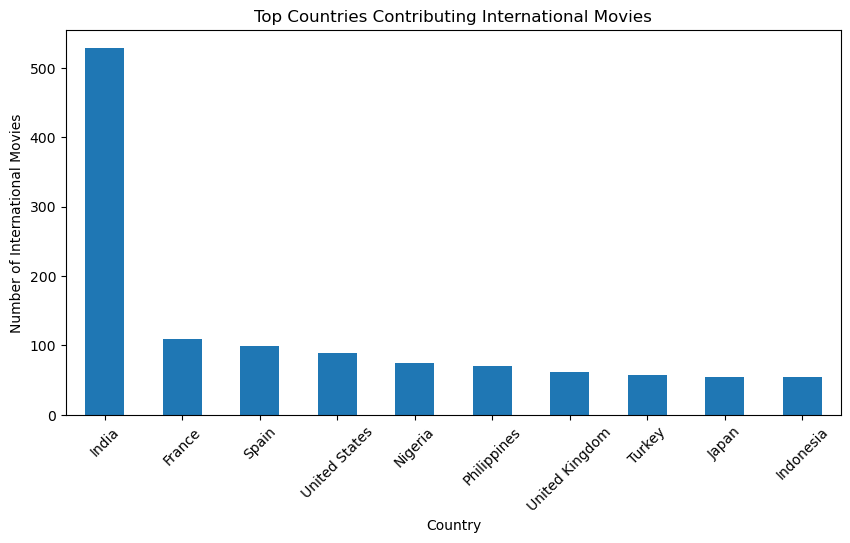

In [28]:
#3. Which countries contribute the most International Movies?
international_movies = data[data["listed_in"].str.contains("International Movies", na=False)] # Filter International Movies
# Split multiple countries into separate rows
countries = (international_movies["country"].str.split(", ").explode().value_counts().head(10))
display(countries)
# Plot
plt.figure(figsize=(10,5))
countries.plot(kind='bar')
plt.title("Top Countries Contributing International Movies")
plt.xlabel("Country")
plt.ylabel("Number of International Movies")
plt.xticks(rotation=45)
plt.show()

Observation:
* The analysis shows that a few countries contribute a large share of International Movies available on Netflix.
* Countries with strong film industries and global audience reach dominate international content production.
* The results also highlight Netflix’s strategy of expanding culturally diverse content to attract viewers from different regions around the world.

director
N/A                    1882
Rajiv Chilaka            19
Jan Suter                15
Suhas Kadav              15
Raúl Campos              14
Marcus Raboy             13
Cathy Garcia-Molina      12
Youssef Chahine          12
Jay Chapman               9
Fernando Ayllón           8
Name: count, dtype: int64

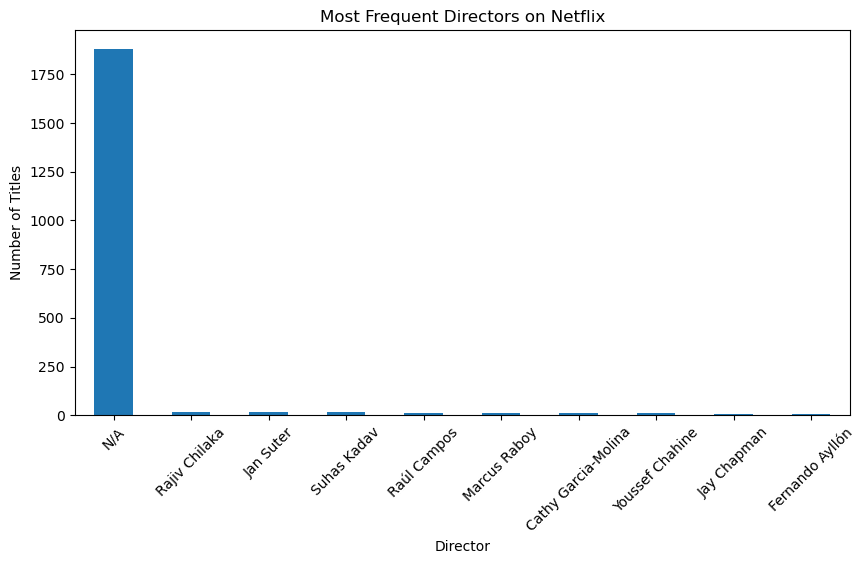

In [29]:
#4. Which directors appear most frequently?
director_count = (data["director"].str.split(", ").explode().value_counts().head(10)) # Split multiple directors into separate rows
display(director_count)
# Plot
plt.figure(figsize=(10,5))
director_count.plot(kind='bar')
plt.title("Most Frequent Directors on Netflix")
plt.xlabel("Director")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

Observation:
* The analysis shows that a small group of directors appear repeatedly across Netflix titles.
* These directors likely have strong industry recognition, higher audience popularity, and ongoing collaborations with Netflix or production studios.
* The concentration of titles among certain directors reflects the platform’s preference for experienced and commercially successful content creators.

cast
Takahiro Sakurai    26
Anupam Kher         25
Rajesh Kava         25
Yuki Kaji           24
Julie Tejwani       24
Rupa Bhimani        22
Jigna Bhardwaj      22
Vincent Tong        22
Junichi Suwabe      20
Daisuke Ono         20
Name: count, dtype: int64

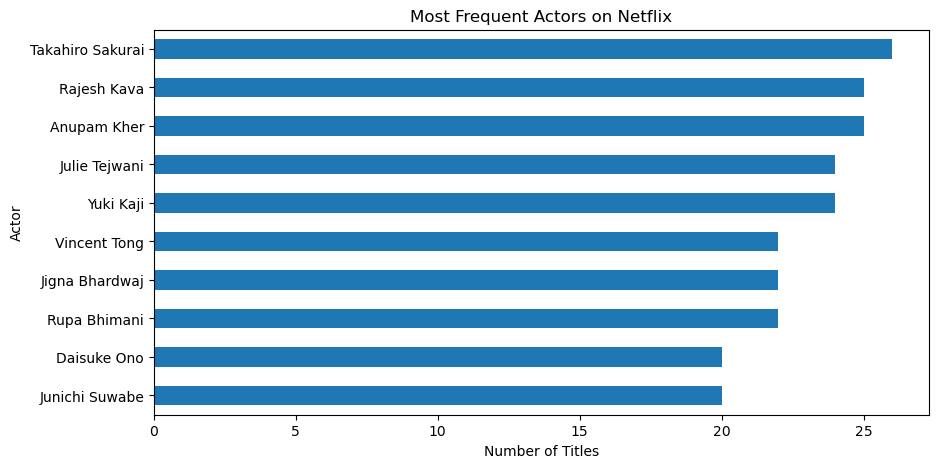

In [30]:
#5. Which actors appear most frequently?
actor_count = (data["cast"].str.split(", ").explode().value_counts().head(10))
display(actor_count)
# Plot
plt.figure(figsize=(10,5))
actor_count.sort_values().plot(kind='barh')
plt.title("Most Frequent Actors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Actor")
plt.show()

Observation:
* The analysis shows that certain actors appear frequently across Netflix titles, indicating strong industry presence and audience popularity.
* Repeated appearances may reflect long-term collaborations with production studios and high viewer demand for familiar performers.
* The results also highlight Netflix’s focus on featuring widely recognized actors to increase audience engagement.

type
Movie      64.183806
TV Show    35.816194
Name: proportion, dtype: float64

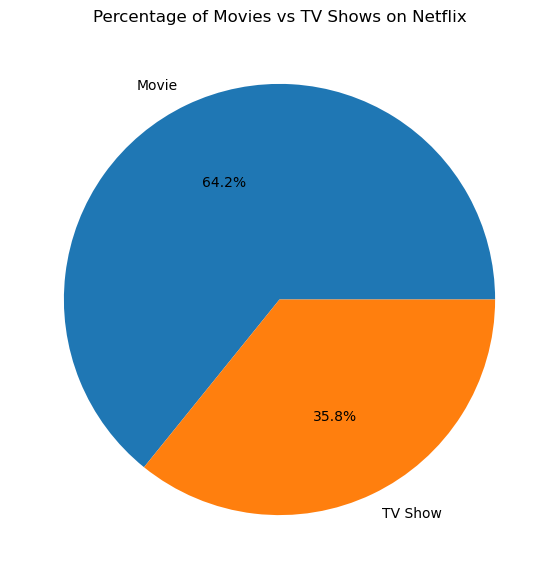

In [31]:
#Business & Audience Insights
#1. What percentage of Netflix content is Movies vs TV Shows?
content_percentage = (data["type"].value_counts(normalize=True) * 100)   # Calculate percentage distribution
display(content_percentage)
# Plot Pie Chart
plt.figure(figsize=(7,7))
plt.pie(content_percentage,labels=content_percentage.index,autopct='%1.1f%%')
plt.title("Percentage of Movies vs TV Shows on Netflix")
plt.show()

Observation:
* The analysis shows that Movies make up the majority of Netflix content, while TV Shows represent a smaller portion of the platform’s catalog.
* This indicates that Netflix places stronger emphasis on movie distribution, although TV Shows continue to grow steadily due to increasing audience demand for episodic entertainment.

rating
TV-MA    41.615712
TV-14    25.440059
TV-PG     8.615898
R         6.800074
TV-Y      4.261627
PG-13     4.187512
TV-Y7     3.872522
TV-G      2.668149
PG        2.279044
G         0.240875
NC-17     0.018529
Name: proportion, dtype: float64

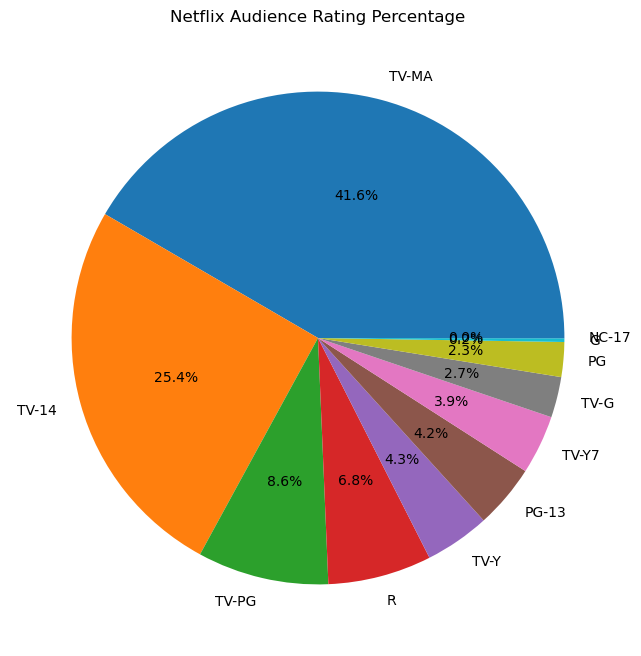

In [32]:
#2. Which audience rating dominates Netflix?
# Calculate percentage
rating_percentage = (data["rating"].value_counts(normalize=True) * 100)
display(rating_percentage)
# Pie chart
plt.figure(figsize=(8,8))
plt.pie(rating_percentage,labels=rating_percentage.index,autopct='%1.1f%%')
plt.title("Netflix Audience Rating Percentage")
plt.show()

Observation:
* The analysis shows that TV-MA and TV-14 ratings dominate Netflix content, indicating a strong focus on mature and teenage audiences.
* This suggests that Netflix primarily targets viewers seeking adult-oriented entertainment, drama, crime series, and mature storytelling content.
* Family-friendly and children’s content are present but represent a smaller share of the platform.

'Average Movie Duration:'

np.float64(100.38799076212472)

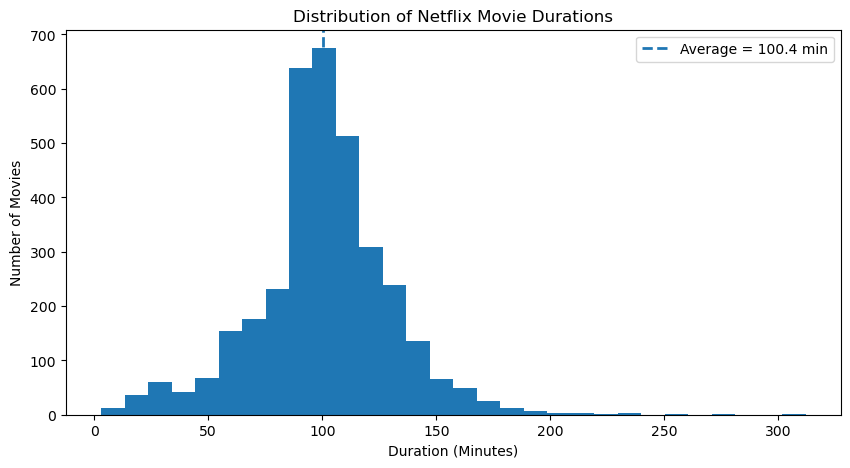

In [33]:
#3. How long are Netflix movies on average?
movies = data[data["type"] == "Movie"].copy()   # Filter only Movies
movies["duration_int"] = (movies["duration"].str.replace(" min", "").astype(int)) # Extract numeric duration
average_duration = movies["duration_int"].mean()   # Calculate average duration
display("Average Movie Duration:", average_duration)
# Histogram
plt.figure(figsize=(10,5))
plt.hist(movies["duration_int"],bins=30)
# Average line
plt.axvline(average_duration,linestyle='dashed',linewidth=2,label=f'Average = {average_duration:.1f} min')
plt.title("Distribution of Netflix Movie Durations")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")
plt.legend()
plt.show()

Observation:
* The analysis shows that Netflix movies generally have moderate durations, with most films ranging between 80 and 120 minutes.
* Extremely short and very long movies are less common.
* This suggests that Netflix prioritizes content lengths that align with mainstream audience viewing preferences and engagement patterns.

listed_in
International TV Shows    1000
TV Dramas                  576
TV Comedies                436
Crime TV Shows             349
Kids' TV                   321
Romantic TV Shows          253
Docuseries                 248
Reality TV                 185
Anime Series               149
TV Action & Adventure      143
Name: count, dtype: int64

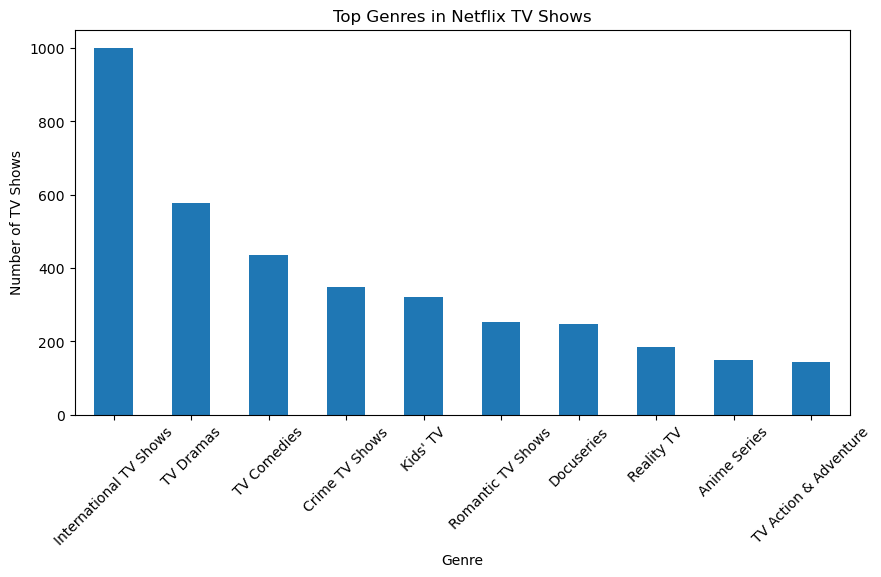

In [34]:
#4. Which genres dominate TV Shows?
tv_shows = data[data["type"] == "TV Show"] # Filter only TV Shows
# Split genres into separate rows
tv_genres = (tv_shows["listed_in"].str.split(", ").explode().value_counts().head(10))
display(tv_genres)
# Plot
plt.figure(figsize=(10,5))
tv_genres.plot(kind='bar')
plt.title("Top Genres in Netflix TV Shows")
plt.xlabel("Genre")
plt.ylabel("Number of TV Shows")
plt.xticks(rotation=45)
plt.show()

Observation:
* The analysis shows that International TV Shows, TV Dramas, and Crime TV Shows are among the most dominant genres on Netflix.
* This indicates strong audience demand for serialized storytelling, suspense-driven content, and globally diverse entertainment.
* The results also reflect Netflix’s increasing investment in international and genre-specific television content.

added_year
2017    43
2018    64
2019    64
2020    70
2021    73
Name: Country, dtype: int64

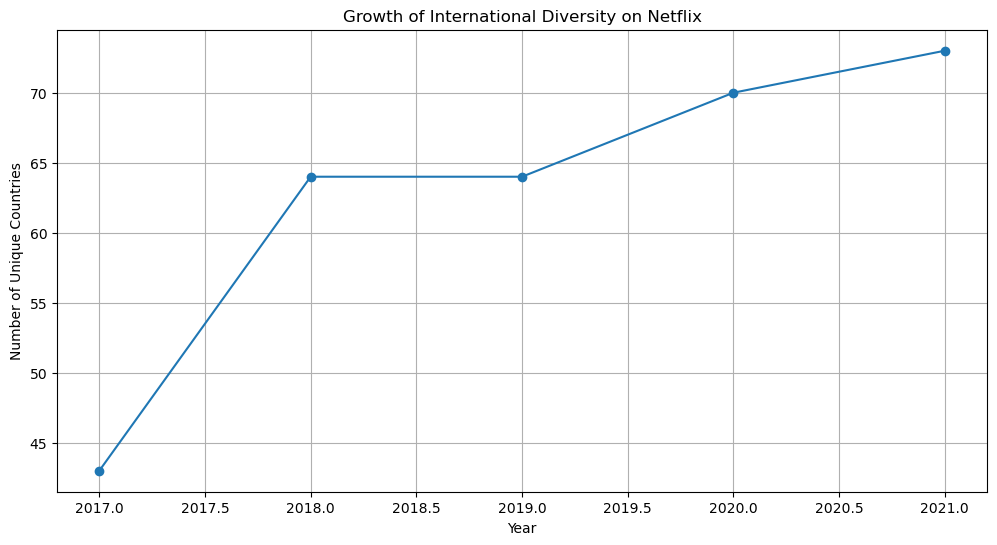

In [35]:
#5. Are Netflix titles becoming more internationally diverse?
data["added_year"] = data["date_added"].dt.year   # Extract added year
country_df = data.assign(Country=data["country"].str.split(", ")).explode("Country")  # Split multiple countries into separate rows
diversity_trend = (country_df.groupby("added_year")["Country"].nunique()) # Count unique countries by year
display(diversity_trend)
# Plot
plt.figure(figsize=(12,6))
plt.plot(diversity_trend.index,diversity_trend.values,marker='o')
plt.title("Growth of International Diversity on Netflix")
plt.xlabel("Year")
plt.ylabel("Number of Unique Countries")
plt.grid(True)
plt.show()

Observation:
* The analysis indicates that Netflix titles have become increasingly internationally diverse over time. The number of countries contributing content to the platform has steadily grown, reflecting Netflix’s global expansion strategy and investment in regional entertainment industries.
* This diversification helps Netflix attract broader international audiences and support culturally diverse viewing preferences.